# Understanding Data Types in Python

Effective data-driven science and computation requires understanding how data is stored and manipulated.
This chapter outlines and contrasts how arrays of data are handled in the Python language itself, and how NumPy improves on this.
Understanding this difference is fundamental to understanding much of the material throughout the rest of the book.

Users of Python are often drawn in by its ease of use, one piece of which is dynamic typing.
While a statically typed language like C or Java requires each variable to be explicitly declared, a dynamically typed language like Python skips this specification. For example, in C you might specify a particular operation as follows:

```C
/* C code */
int result = 0;
for(int i=0; i<100; i++){
    result += i;
}
```

While in Python the equivalent operation could be written this way:

```python
# Python code
result = 0
for i in range(100):
    result += i
```

Notice one main difference: in C, the data types of each variable are explicitly declared, while in Python the types are dynamically inferred. This means, for example, that we can assign any kind of data to any variable:

```python
# Python code
x = 4
x = "four"
```

Here we've switched the contents of `x` from an integer to a string. The same thing in C would lead (depending on compiler settings) to a compilation error or other unintended consequences:

```C
/* C code */
int x = 4;
x = "four";  // FAILS
```

This sort of flexibility is one element that makes Python and other dynamically typed languages convenient and easy to use.
Understanding *how* this works is an important piece of learning to analyze data efficiently and effectively with Python.
But what this type flexibility also points to is the fact that Python variables are more than just their values; they also contain extra information about the *type* of the value. We'll explore this more in the sections that follow.

## A Python Integer Is More Than Just an Integer

The standard Python implementation is written in C.
This means that every Python object is simply a cleverly disguised C structure, which contains not only its value, but other information as well. For example, when we define an integer in Python, such as `x = 10000`, `x` is not just a "raw" integer. It's actually a pointer to a compound C structure, which contains several values.
Looking through the Python 3.10 source code, we find that the integer (long) type definition effectively looks like this (once the C macros are expanded):

```C
struct _longobject {
    long ob_refcnt;
    PyTypeObject *ob_type;
    size_t ob_size;
    long ob_digit[1];
};
```

A single integer in Python 3.10 actually contains four pieces:

- `ob_refcnt`, a reference count that helps Python silently handle memory allocation and deallocation
- `ob_type`, which encodes the type of the variable
- `ob_size`, which specifies the size of the following data members
- `ob_digit`, which contains the actual integer value that we expect the Python variable to represent

This means that there is some overhead involved in storing an integer in Python as compared to a compiled language like C, as illustrated in the following figure:

![Integer Memory Layout](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/images/cint_vs_pyint.png?raw=1)

Here, `PyObject_HEAD` is the part of the structure containing the reference count, type code, and other pieces mentioned before.

Notice the difference here: a C integer is essentially a label for a position in memory whose bytes encode an integer value.
A Python integer is a pointer to a position in memory containing all the Python object information, including the bytes that contain the integer value.
This extra information in the Python integer structure is what allows Python to be coded so freely and dynamically.
All this additional information in Python types comes at a cost, however, which becomes especially apparent in structures that combine many of these objects.

## A Python List Is More Than Just a List

Let's consider now what happens when we use a Python data structure that holds many Python objects.
The standard mutable multielement container in Python is the list.
We can create a list of integers as follows:

In [ ]:
L = list(range(10))
L

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [ ]:
type(L[0])

int

Or, similarly, a list of strings:

In [ ]:
L2 = [str(c) for c in L]
L2

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

In [ ]:
type(L2[0])

str

Because of Python's dynamic typing, we can even create heterogeneous lists:

In [ ]:
L3 = [True, "2", 3.0, 4]
[type(item) for item in L3]

[bool, str, float, int]

But this flexibility comes at a cost: to allow these flexible types, each item in the list must contain its own type, reference count, and other information. That is, each item is a complete Python object.
In the special case that all variables are of the same type, much of this information is redundant, so it can be much more efficient to store the data in a fixed-type array.
The difference between a dynamic-type list and a fixed-type (NumPy-style) array is illustrated in the following figure:

![Array Memory Layout](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/images/array_vs_list.png?raw=1)

At the implementation level, the array essentially contains a single pointer to one contiguous block of data.
The Python list, on the other hand, contains a pointer to a block of pointers, each of which in turn points to a full Python object like the Python integer we saw earlier.
Again, the advantage of the list is flexibility: because each list element is a full structure containing both data and type information, the list can be filled with data of any desired type.
Fixed-type NumPy-style arrays lack this flexibility, but are much more efficient for storing and manipulating data.

## Fixed-Type Arrays in Python

Python offers several different options for storing data in efficient, fixed-type data buffers.
The built-in `array` module (available since Python 3.3) can be used to create dense arrays of a uniform type:

In [ ]:
import array
L = list(range(10))
A = array.array('i', L)
A

array('i', [0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

Here, `'i'` is a type code indicating the contents are integers.

Much more useful, however, is the `ndarray` object of the NumPy package.
While Python's `array` object provides efficient storage of array-based data, NumPy adds to this efficient *operations* on that data.
We will explore these operations in later chapters; next, I'll show you a few different ways of creating a NumPy array.

## Creating Arrays from Python Lists

We'll start with the standard NumPy import, under the alias `np`:

In [3]:
import numpy as np

Now we can use `np.array` to create arrays from Python lists:

In [ ]:
# Integer array
np.array([1, 4, 2, 5, 3])

array([1, 4, 2, 5, 3])

Remember that unlike Python lists, NumPy arrays can only contain data of the same type.
If the types do not match, NumPy will upcast them according to its type promotion rules; here, integers are upcast to floating point:

In [ ]:
np.array([3.14, 4, 2, 3])

array([3.14, 4.  , 2.  , 3.  ])

If we want to explicitly set the data type of the resulting array, we can use the `dtype` keyword:

In [ ]:
np.array([1, 2, 3, 4], dtype=np.float32)

array([1., 2., 3., 4.], dtype=float32)

Finally, unlike Python lists, which are always one-dimensional sequences, NumPy arrays can be multidimensional. Here's one way of initializing a multidimensional array using a list of lists:

In [ ]:
# Nested lists result in multidimensional arrays
np.array([range(i, i + 3) for i in [2, 4, 6]])

array([[2, 3, 4],
       [4, 5, 6],
       [6, 7, 8]])

The inner lists are treated as rows of the resulting two-dimensional array.

## Creating Arrays from Scratch

Especially for larger arrays, it is more efficient to create arrays from scratch using routines built into NumPy.
Here are several examples:

In [ ]:
# Create a length-10 integer array filled with 0s
np.zeros(10, dtype=int)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
# Create a 3x5 floating-point array filled with 1s
np.ones((3, 5), dtype=float)

array([[1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.]])

In [ ]:
# Create a 3x5 array filled with 3.14
np.full((3, 5), 3.14)

array([[3.14, 3.14, 3.14, 3.14, 3.14],
       [3.14, 3.14, 3.14, 3.14, 3.14],
       [3.14, 3.14, 3.14, 3.14, 3.14]])

In [8]:
# Create an array filled with a linear sequence
# starting at 0, ending at 20, stepping by 2
# (this is similar to the built-in range function)
np.arange( 0, 20, 2).reshape(2,5)

TypeError: unsupported operand type(s) for /: 'int' and 'tuple'

In [ ]:
# Create an array of five values evenly spaced between 0 and 1
np.linspace(0, 1, 5)

array([0.  , 0.25, 0.5 , 0.75, 1.  ])

In [ ]:
# Create a 3x3 array of uniformly distributed
# pseudorandom values between 0 and 1
np.random.random((3, 3))

array([[0.09610171, 0.88193001, 0.70548015],
       [0.35885395, 0.91670468, 0.8721031 ],
       [0.73237865, 0.09708562, 0.52506779]])

In [ ]:
# Create a 3x3 array of normally distributed pseudorandom
# values with mean 0 and standard deviation 1
np.random.normal(0, 1, (3, 3))

array([[-0.46652655, -0.59158776, -1.05392451],
       [-1.72634268,  0.03194069, -0.51048869],
       [ 1.41240208,  1.77734462, -0.43820037]])

In [ ]:
# Create a 3x3 array of pseudorandom integers in the interval [0, 10)
np.random.randint(0, 10, (3, 3))

array([[4, 3, 8],
       [6, 5, 0],
       [1, 1, 4]])

In [ ]:
# Create a 3x3 identity matrix
np.eye(3)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [ ]:
# Create an uninitialized array of three integers; the values will be
# whatever happens to already exist at that memory location
np.empty(3)

array([1., 1., 1.])

## NumPy Standard Data Types

NumPy arrays contain values of a single type, so it is important to have detailed knowledge of those types and their limitations.
Because NumPy is built in C, the types will be familiar to users of C, Fortran, and other related languages.

The standard NumPy data types are listed in the following table.
Note that when constructing an array, they can be specified using a string:

```python
np.zeros(10, dtype='int16')
```

Or using the associated NumPy object:

```python
np.zeros(10, dtype=np.int16)
```

| Data type	 | Description |
|-------------|-------------|
| `bool_`     | Boolean (True or False) stored as a byte |
| `int_`      | Default integer type (same as C `long`; normally either `int64` or `int32`)|
| `intc`      | Identical to C `int` (normally `int32` or `int64`)|
| `intp`      | Integer used for indexing (same as C `ssize_t`; normally either `int32` or `int64`)|
| `int8`      | Byte (–128 to 127)|
| `int16`     | Integer (–32768 to 32767)|
| `int32`     | Integer (–2147483648 to 2147483647)|
| `int64`     | Integer (–9223372036854775808 to 9223372036854775807)|
| `uint8`     | Unsigned integer (0 to 255)|
| `uint16`    | Unsigned integer (0 to 65535)|
| `uint32`    | Unsigned integer (0 to 4294967295)|
| `uint64`    | Unsigned integer (0 to 18446744073709551615)|
| `float_`    | Shorthand for `float64`|
| `float16`   | Half-precision float: sign bit, 5 bits exponent, 10 bits mantissa|
| `float32`   | Single-precision float: sign bit, 8 bits exponent, 23 bits mantissa|
| `float64`   | Double-precision float: sign bit, 11 bits exponent, 52 bits mantissa|
| `complex_`  | Shorthand for `complex128`|
| `complex64` | Complex number, represented by two 32-bit floats|
| `complex128`| Complex number, represented by two 64-bit floats|

More advanced type specification is possible, such as specifying big- or little-endian numbers; for more information, refer to the [NumPy documentation](http://numpy.org/).
NumPy also supports compound data types, which will be covered in [Structured Data: NumPy's Structured Arrays](02.09-Structured-Data-NumPy.ipynb).

# The Basics of NumPy Arrays

Data manipulation in Python is nearly synonymous with NumPy array manipulation: even newer tools like Pandas ([Part 3](03.00-Introduction-to-Pandas.ipynb)) are built around the NumPy array.
This chapter will present several examples of using NumPy array manipulation to access data and subarrays, and to split, reshape, and join the arrays.
While the types of operations shown here may seem a bit dry and pedantic, they comprise the building blocks of many other examples used throughout the book.
Get to know them well!

We'll cover a few categories of basic array manipulations here:

- *Attributes of arrays*: Determining the size, shape, memory consumption, and data types of arrays
- *Indexing of arrays*: Getting and setting the values of individual array elements
- *Slicing of arrays*: Getting and setting smaller subarrays within a larger array
- *Reshaping of arrays*: Changing the shape of a given array
- *Joining and splitting of arrays*: Combining multiple arrays into one, and splitting one array into many

## NumPy Array Attributes

First let's discuss some useful array attributes.
We'll start by defining random arrays of one, two, and three dimensions.
We'll use NumPy's random number generator, which we will *seed* with a set value in order to ensure that the same random arrays are generated each time this code is run:

In [10]:
import numpy as np
rng = np.random.default_rng(seed=1701)  # seed for reproducibility

x1 = rng.integers(10, size=6)  # one-dimensional array
x2 = rng.integers(10, size=(3, 4))  # two-dimensional array
x3 = rng.integers(10, size=(3, 4, 5))  # three-dimensional array

Each array has attributes including `ndim` (the number of dimensions), `shape` (the size of each dimension), `size` (the total size of the array), and `dtype` (the type of each element):

In [ ]:
print("x3 ndim: ", x3.ndim)
print("x3 shape:", x3.shape)
print("x3 size: ", x3.size)
print("dtype:   ", x3.dtype)

x3 ndim:  3
x3 shape: (3, 4, 5)
x3 size:  60
dtype:    int64


For more discussion of data types, see [Understanding Data Types in Python](02.01-Understanding-Data-Types.ipynb).

## Array Indexing: Accessing Single Elements

If you are familiar with Python's standard list indexing, indexing in NumPy will feel quite familiar.
In a one-dimensional array, the $i^{th}$ value (counting from zero) can be accessed by specifying the desired index in square brackets, just as with Python lists:

In [ ]:
x1

array([9, 4, 0, 3, 8, 6])

In [ ]:
x1[0]

9

In [ ]:
x1[4]

8

To index from the end of the array, you can use negative indices:

In [ ]:
x1[-1]

6

In [ ]:
x1[-2]

8

In a multidimensional array, items can be accessed using a comma-separated `(row, column)` tuple:

In [ ]:
x2

array([[3, 1, 3, 7],
       [4, 0, 2, 3],
       [0, 0, 6, 9]])

In [ ]:
x2[0, 0]

3

In [ ]:
x2[2, 0]

0

In [ ]:
x2[2, -1]

9

Values can also be modified using any of the preceding index notation:

In [ ]:
x2[0, 0] = 12
x2

array([[12,  1,  3,  7],
       [ 4,  0,  2,  3],
       [ 0,  0,  6,  9]])

Keep in mind that, unlike Python lists, NumPy arrays have a fixed type.
This means, for example, that if you attempt to insert a floating-point value into an integer array, the value will be silently truncated. Don't be caught unaware by this behavior!

In [ ]:
x1[0] = 3.14159  # this will be truncated!
x1

array([3, 4, 0, 3, 8, 6])

## Array Slicing: Accessing Subarrays

Just as we can use square brackets to access individual array elements, we can also use them to access subarrays with the *slice* notation, marked by the colon (`:`) character.
The NumPy slicing syntax follows that of the standard Python list; to access a slice of an array `x`, use this:
``` python
x[start:stop:step]
```
If any of these are unspecified, they default to the values `start=0`, `stop=<size of dimension>`, `step=1`.
Let's look at some examples of accessing subarrays in one dimension and in multiple dimensions.

### One-Dimensional Subarrays

Here are some examples of accessing elements in one-dimensional subarrays:

In [ ]:
x1

array([3, 4, 0, 3, 8, 6])

In [ ]:
x1[:3]  # first three elements

array([3, 4, 0])

In [ ]:
x1[3:]  # elements after index 3

array([3, 8, 6])

In [ ]:
x1[1:4]  # middle subarray

array([4, 0, 3])

slicing: it includes the  starting value  , but not the ending one,   like if the slicing is [0:4] ,then it includes 0,1,2 and 3 , but not 4 ..

In [ ]:
x1[::2]  # every second element

array([3, 0, 8])

In [ ]:
x1[1::2]  # every second element, starting at index 1

array([4, 3, 6])

A potentially confusing case is when the `step` value is negative.
In this case, the defaults for `start` and `stop` are swapped.
This becomes a convenient way to reverse an array:

In [ ]:
x1[::-1]  # all elements, reversed

array([6, 8, 3, 0, 4, 3])

In [ ]:
x1[4::-2]  # every second element from index 4, reversed

array([8, 0, 3])

### Multidimensional Subarrays

Multidimensional slices work in the same way, with multiple slices separated by commas.
For example:

In [ ]:
x2

array([[12,  1,  3,  7],
       [ 4,  0,  2,  3],
       [ 0,  0,  6,  9]])

In [ ]:
x2[:2, :3]  # first two rows & three columns

array([[12,  1,  3],
       [ 4,  0,  2]])

**For 2d and higher dimension arrays,  we just write each rows and columns slicing seperately using comma .   if a= [2,3,4] we write  a[::-1] to reverse a 1d array,   then when a= ([2,3,4],[3,4,5]) , then reverseing means  a[::-1,::-1]**

In [11]:
#Example:
a1=np.array([[2,3,4],[3,4,5]])
a1[::-1,::-1]   #both rows and col reversed

array([[5, 4, 3],
       [4, 3, 2]])

In [15]:
a1[::,::-1] #only col reversed

array([[4, 3, 2],
       [5, 4, 3]])

In [ ]:
x2[:3, ::2]  # three rows, every second column

array([[12,  3],
       [ 4,  2],
       [ 0,  6]])

In [ ]:
x2[::-1, ::-1]  # all rows & columns, reversed

array([[ 9,  6,  0,  0],
       [ 3,  2,  0,  4],
       [ 7,  3,  1, 12]])

#### Accessing array rows and columns

One commonly needed routine is accessing single rows or columns of an array.
This can be done by combining indexing and slicing, using an empty slice marked by a single colon (`:`):

In [ ]:
x2[:, 0]  # first column of x2

array([12,  4,  0])

In [ ]:
x2[0, :]  # first row of x2

array([12,  1,  3,  7])

In the case of row access, the empty slice can be omitted for a more compact syntax:

In [ ]:
x2[0]  # equivalent to x2[0, :]

array([12,  1,  3,  7])

### Subarrays as No-Copy Views

Unlike Python list slices, NumPy array slices are returned as *views* rather than *copies* of the array data.
Consider our two-dimensional array from before:

In [ ]:
print(x2)

[[12  1  3  7]
 [ 4  0  2  3]
 [ 0  0  6  9]]


Let's extract a $2 \times 2$ subarray from this:

In [17]:
x2_sub = x2[:2, :2]
print(x2_sub)

[[3 1]
 [4 0]]


Now if we modify this subarray, we'll see that the original array is changed! Observe:

In [18]:
x2_sub[0, 0] = 99
x2_sub[1,1]=47
print(x2_sub)

[[99  1]
 [ 4 47]]


In [19]:
print(x2)

[[99  1  3  7]
 [ 4 47  2  3]
 [ 0  0  6  9]]


Some users may find this surprising, but it can be advantageous: for example, when working with large datasets, we can access and process pieces of these datasets without the need to copy the underlying data buffer.

### Creating Copies of Arrays

Despite the nice features of array views, it is sometimes useful to instead explicitly copy the data within an array or a subarray. This can be most easily done with the `copy` method:

In [ ]:
x2_sub_copy = x2[:2, :2].copy()
print(x2_sub_copy)

[[99  1]
 [ 4  0]]


If we now modify this subarray, the original array is not touched:

In [ ]:
x2_sub_copy[0, 0] = 42
print(x2_sub_copy)

[[42  1]
 [ 4  0]]


In [ ]:
print(x2)

[[99  1  3  7]
 [ 4  0  2  3]
 [ 0  0  6  9]]


## Reshaping of Arrays

Another useful type of operation is reshaping of arrays, which can be done with the `reshape` method.
For example, if you want to put the numbers 1 through 9 in a $3 \times 3$ grid, you can do the following:

In [ ]:
grid = np.arange(1, 10).reshape(3, 3)
print(grid)

[[1 2 3]
 [4 5 6]
 [7 8 9]]


Note that for this to work, the size of the initial array must match the size of the reshaped array, and in most cases the `reshape` method will return a no-copy view of the initial array.

A common reshaping operation is converting a one-dimensional array into a two-dimensional row or column matrix:

In [ ]:
x = np.array([1, 2, 3])
x.reshape((1, 3))  # row vector via reshape

array([[1, 2, 3]])

In [ ]:
x.reshape((3, 1))  # column vector via reshape

array([[1],
       [2],
       [3]])

A convenient shorthand for this is to use `np.newaxis` in the slicing syntax:

In [ ]:
x[np.newaxis, :]  # row vector via newaxis

array([[1, 2, 3]])

In [ ]:
x[:, np.newaxis]  # column vector via newaxis

array([[1],
       [2],
       [3]])

This is a pattern that we will utilize often throughout the remainder of the book.

## Array Concatenation and Splitting

All of the preceding routines worked on single arrays. NumPy also provides tools to combine multiple arrays into one, and to conversely split a single array into multiple arrays.

### Concatenation of Arrays

Concatenation, or joining of two arrays in NumPy, is primarily accomplished using the routines `np.concatenate`, `np.vstack`, and `np.hstack`.
`np.concatenate` takes a tuple or list of arrays as its first argument, as you can see here:

In [31]:
x = np.array([1, 2, 3])
y = np.array([3, 2, 1])
np.concatenate([x, y])

array([1, 2, 3, 3, 2, 1])

You can also concatenate more than two arrays at once:

In [ ]:
z = np.array([99, 99, 99])
print(np.concatenate([x, y, z]))

[ 1  2  3  3  2  1 99 99 99]


And it can be used for two-dimensional arrays:

In [25]:
grid = np.array([[1, 2, 3],
                 [4, 5, 6],
                 [6,7,8]])

In [26]:
# concatenate along the first axis
np.concatenate([grid, grid])

array([[1, 2, 3],
       [4, 5, 6],
       [6, 7, 8],
       [1, 2, 3],
       [4, 5, 6],
       [6, 7, 8]])

In [29]:
# concatenate along the second axis (zero-indexed)
np.concatenate([grid, grid], axis=1)

array([[1, 2, 3, 1, 2, 3],
       [4, 5, 6, 4, 5, 6],
       [6, 7, 8, 6, 7, 8]])

**If we want to add verticaly and thus create more rows after addition, then its axix 0 or vstack . and if we want to ad horizontaly and create more columns, then axis 1 or hstack**

For working with arrays of mixed dimensions, it can be clearer to use the `np.vstack` (vertical stack) and `np.hstack` (horizontal stack) functions:

In [32]:
# vertically stack the arrays
np.vstack([x, grid])

array([[1, 2, 3],
       [1, 2, 3],
       [4, 5, 6],
       [6, 7, 8]])

In [ ]:
# horizontally stack the arrays
y = np.array([[99],
              [99]])
np.hstack([grid, y])

array([[ 1,  2,  3, 99],
       [ 4,  5,  6, 99]])

Similarly, for higher-dimensional arrays, `np.dstack` will stack arrays along the third axis.

### Splitting of Arrays

The opposite of concatenation is splitting, which is implemented by the functions `np.split`, `np.hsplit`, and `np.vsplit`.  For each of these, we can pass a list of indices giving the split points:

In [ ]:
x = [1, 2, 3, 99, 99, 3, 2, 1]
x1, x2, x3 = np.split(x, [3, 5])
print(x1, x2, x3)

[1 2 3] [99 99] [3 2 1]


Notice that *N* split points leads to *N* + 1 subarrays.
The related functions `np.hsplit` and `np.vsplit` are similar:

In [ ]:
grid = np.arange(16).reshape((4, 4))
grid

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15]])

In [ ]:
upper, lower = np.vsplit(grid, [2])
print(upper)
print(lower)

[[0 1 2 3]
 [4 5 6 7]]
[[ 8  9 10 11]
 [12 13 14 15]]


**For splitting rows and cols , we use hsplit and vsplit .  hsplit is used to divide in cols  while vsplit to divide by rows. .  eg if a matrix has 4x4 rows and cols and we use vsplit 2, then each sub array has 2x4 rows. .  similarly if we use hsplit, then each subarray has 4 x2 **

In [ ]:
left, right = np.hsplit(grid, [2])
print(left)
print(right)

[[ 0  1]
 [ 4  5]
 [ 8  9]
 [12 13]]
[[ 2  3]
 [ 6  7]
 [10 11]
 [14 15]]


Similarly, for higher-dimensional arrays, `np.dsplit` will split arrays along the third axis.

# Computation on NumPy Arrays: Universal Functions

Up until now, we have been discussing some of the basic nuts and bolts of NumPy. In the next few chapters, we will dive into the reasons that NumPy is so important in the Python data science world: namely, because it provides an easy and flexible interface to optimize computation with arrays of data.

Computation on NumPy arrays can be very fast, or it can be very slow.
The key to making it fast is to use vectorized operations, generally implemented through NumPy's *universal functions* (ufuncs).
This chapter motivates the need for NumPy's ufuncs, which can be used to make repeated calculations on array elements much more efficient.
It then introduces many of the most common and useful arithmetic ufuncs available in the NumPy package.

## The Slowness of Loops

Python's default implementation (known as CPython) does some operations very slowly.
This is partly due to the dynamic, interpreted nature of the language; types are flexible, so sequences of operations cannot be compiled down to efficient machine code as in languages like C and Fortran.
Recently there have been various attempts to address this weakness: well-known examples are the [PyPy project](http://pypy.org/), a just-in-time compiled implementation of Python; the [Cython project](http://cython.org), which converts Python code to compilable C code; and the [Numba project](http://numba.pydata.org/), which converts snippets of Python code to fast LLVM bytecode.
Each of these has its strengths and weaknesses, but it is safe to say that none of the three approaches has yet surpassed the reach and popularity of the standard CPython engine.

The relative sluggishness of Python generally manifests itself in situations where many small operations are being repeated; for instance, looping over arrays to operate on each element.
For example, imagine we have an array of values and we'd like to compute the reciprocal of each.
A straightforward approach might look like this:

In [34]:
import numpy as np
rng = np.random.default_rng(seed=1701)

def compute_reciprocals(values):
    output = np.empty(len(values))
    for i in range(len(values)):
        output[i] = 1.0 / values[i]
    return output

values = rng.integers(1, 10, size=5)
compute_reciprocals(values)

array([0.11111111, 0.25      , 1.        , 0.33333333, 0.125     ])

This implementation probably feels fairly natural to someone from, say, a C or Java background.
But if we measure the execution time of this code for a large input, we see that this operation is very slow—perhaps surprisingly so!
We'll benchmark this with IPython's `%timeit` magic (discussed in [Profiling and Timing Code](01.07-Timing-and-Profiling.ipynb)):

In [35]:
big_array = rng.integers(1, 100, size=1000000)
%timeit compute_reciprocals(big_array)

2.59 s ± 568 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


It takes several seconds to compute these million operations and to store the result!
When even cell phones have processing speeds measured in gigaflops (i.e., billions of numerical operations per second), this seems almost absurdly slow.
It turns out that the bottleneck here is not the operations themselves, but the type checking and function dispatches that CPython must do at each cycle of the loop.
Each time the reciprocal is computed, Python first examines the object's type and does a dynamic lookup of the correct function to use for that type.
If we were working in compiled code instead, this type specification would be known before the code executed and the result could be computed much more efficiently.

## Introducing Ufuncs

For many types of operations, NumPy provides a convenient interface into just this kind of statically typed, compiled routine. This is known as a *vectorized* operation.
For simple operations like the element-wise division here, vectorization is as simple as using Python arithmetic operators directly on the array object.
This vectorized approach is designed to push the loop into the compiled layer that underlies NumPy, leading to much faster execution.

Compare the results of the following two operations:

In [36]:
print(compute_reciprocals(values))
print(1.0 / values)

[0.11111111 0.25       1.         0.33333333 0.125     ]
[0.11111111 0.25       1.         0.33333333 0.125     ]


Looking at the execution time for our big array, we see that it completes orders of magnitude faster than the Python loop:

In [ ]:
#so instead of 1.0/values[i] for i in values which is looping through every i and dividing them and storing result  , we just tell numpy to do  1/ values  , i.e  1 / entire array itself.

In [ ]:
%timeit (1.0 / big_array)

2.54 ms ± 383 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


Vectorized operations in NumPy are implemented via ufuncs, whose main purpose is to quickly execute repeated operations on values in NumPy arrays.
Ufuncs are extremely flexible—before we saw an operation between a scalar and an array, but we can also operate between two arrays:

In [39]:
x=np.arange(5)
x

array([0, 1, 2, 3, 4])

In [37]:
np.arange(5) / np.arange(1, 6)

array([0.        , 0.5       , 0.66666667, 0.75      , 0.8       ])

And ufunc operations are not limited to one-dimensional arrays. They can act on multidimensional arrays as well:

In [ ]:
x = np.arange(9).reshape((3, 3))
2 ** x

array([[  1,   2,   4],
       [  8,  16,  32],
       [ 64, 128, 256]])

Computations using vectorization through ufuncs are nearly always more efficient than their counterparts implemented using Python loops, especially as the arrays grow in size.
Any time you see such a loop in a NumPy script, you should consider whether it can be replaced with a vectorized expression.

## Exploring NumPy's Ufuncs

Ufuncs exist in two flavors: *unary ufuncs*, which operate on a single input, and *binary ufuncs*, which operate on two inputs.
We'll see examples of both these types of functions here.

### Array Arithmetic

NumPy's ufuncs feel very natural to use because they make use of Python's native arithmetic operators.
The standard addition, subtraction, multiplication, and division can all be used:

In [ ]:
x = np.arange(4)
print("x      =", x)
print("x + 5  =", x + 5)
print("x - 5  =", x - 5)
print("x * 2  =", x * 2)
print("x / 2  =", x / 2)
print("x // 2 =", x // 2)  # floor division

x      = [0 1 2 3]
x + 5  = [5 6 7 8]
x - 5  = [-5 -4 -3 -2]
x * 2  = [0 2 4 6]
x / 2  = [0.  0.5 1.  1.5]
x // 2 = [0 0 1 1]


There is also a unary ufunc for negation, a `**` operator for exponentiation, and a `%` operator for modulus:

In [ ]:
print("-x     = ", -x)
print("x ** 2 = ", x ** 2)
print("x % 2  = ", x % 2)

-x     =  [ 0 -1 -2 -3]
x ** 2 =  [0 1 4 9]
x % 2  =  [0 1 0 1]


In addition, these can be strung together however you wish, and the standard order of operations is respected:

In [ ]:
-(0.5*x + 1) ** 2

array([-1.  , -2.25, -4.  , -6.25])

All of these arithmetic operations are simply convenient wrappers around specific ufuncs built into NumPy. For example, the `+` operator is a wrapper for the `add` ufunc:

In [ ]:
np.add(x, 2)

array([2, 3, 4, 5])

The following table lists the arithmetic operators implemented in NumPy:

| Operator    | Equivalent ufunc  | Description                         |
|-------------|-------------------|-------------------------------------|
|`+`          |`np.add`           |Addition (e.g., `1 + 1 = 2`)         |
|`-`          |`np.subtract`      |Subtraction (e.g., `3 - 2 = 1`)      |
|`-`          |`np.negative`      |Unary negation (e.g., `-2`)          |
|`*`          |`np.multiply`      |Multiplication (e.g., `2 * 3 = 6`)   |
|`/`          |`np.divide`        |Division (e.g., `3 / 2 = 1.5`)       |
|`//`         |`np.floor_divide`  |Floor division (e.g., `3 // 2 = 1`)  |
|`**`         |`np.power`         |Exponentiation (e.g., `2 ** 3 = 8`)  |
|`%`          |`np.mod`           |Modulus/remainder (e.g., `9 % 4 = 1`)|

Additionally, there are Boolean/bitwise operators; we will explore these in [Comparisons, Masks, and Boolean Logic](02.06-Boolean-Arrays-and-Masks.ipynb).

### Absolute Value

Just as NumPy understands Python's built-in arithmetic operators, it also understands Python's built-in absolute value function:

In [ ]:
x = np.array([-2, -1, 0, 1, 2])
abs(x)

array([2, 1, 0, 1, 2])

The corresponding NumPy ufunc is `np.absolute`, which is also available under the alias `np.abs`:

In [ ]:
np.absolute(x)

array([2, 1, 0, 1, 2])

In [ ]:
np.abs(x)

array([2, 1, 0, 1, 2])

This ufunc can also handle complex data, in which case it returns the magnitude:

In [ ]:
x = np.array([3 - 4j, 4 - 3j, 2 + 0j, 0 + 1j])
np.abs(x)

array([5., 5., 2., 1.])

### Trigonometric Functions

NumPy provides a large number of useful ufuncs, and some of the most useful for the data scientist are the trigonometric functions.
We'll start by defining an array of angles:

In [ ]:
theta = np.linspace(0, np.pi, 3)

Now we can compute some trigonometric functions on these values:

In [ ]:
print("theta      = ", theta)
print("sin(theta) = ", np.sin(theta))
print("cos(theta) = ", np.cos(theta))
print("tan(theta) = ", np.tan(theta))

theta      =  [0.         1.57079633 3.14159265]
sin(theta) =  [0.0000000e+00 1.0000000e+00 1.2246468e-16]
cos(theta) =  [ 1.000000e+00  6.123234e-17 -1.000000e+00]
tan(theta) =  [ 0.00000000e+00  1.63312394e+16 -1.22464680e-16]


The values are computed to within machine precision, which is why values that should be zero do not always hit exactly zero.  
+ THESE ARE IN RADIANS




Inverse trigonometric functions are also available:

In [ ]:
x = [-1, 0, 1]
print("x         = ", x)
print("arcsin(x) = ", np.arcsin(x))
print("arccos(x) = ", np.arccos(x))
print("arctan(x) = ", np.arctan(x))

x         =  [-1, 0, 1]
arcsin(x) =  [-1.57079633  0.          1.57079633]
arccos(x) =  [3.14159265 1.57079633 0.        ]
arctan(x) =  [-0.78539816  0.          0.78539816]


### Exponents and Logarithms

Other common operations available in NumPy ufuncs are the exponentials:

In [43]:
x = [1, 2, 3]
print("x   =", x)
print("e^x =", np.exp(x))
print("2^x =", np.exp2(x))
print("3^x =", np.power(3., x))
print(np.power(x,x)) # np.power(x,4  gives all x values raised to power 4), and this power(x,x)  means each value in x is raised to tis own values

x   = [1, 2, 3]
e^x = [ 2.71828183  7.3890561  20.08553692]
2^x = [2. 4. 8.]
3^x = [ 3.  9. 27.]
[ 1  4 27]


The inverse of the exponentials, the logarithms, are also available.
The basic `np.log` gives the natural logarithm; if you prefer to compute the base-2 logarithm or the base-10 logarithm, these are available as well:

In [ ]:
x = [1, 2, 4, 10]
print("x        =", x)
print("ln(x)    =", np.log(x))
print("log2(x)  =", np.log2(x))
print("log10(x) =", np.log10(x))

x        = [1, 2, 4, 10]
ln(x)    = [0.         0.69314718 1.38629436 2.30258509]
log2(x)  = [0.         1.         2.         3.32192809]
log10(x) = [0.         0.30103    0.60205999 1.        ]


There are also some specialized versions that are useful for maintaining precision with very small input:

In [ ]:
x = [0, 0.001, 0.01, 0.1]
print("exp(x) - 1 =", np.expm1(x))
print("log(1 + x) =", np.log1p(x))

exp(x) - 1 = [0.         0.0010005  0.01005017 0.10517092]
log(1 + x) = [0.         0.0009995  0.00995033 0.09531018]


When `x` is very small, these functions give more precise values than if the raw `np.log` or `np.exp` were to be used.

### Specialized Ufuncs

NumPy has many more ufuncs available, including for hyperbolic trigonometry, bitwise arithmetic, comparison operations, conversions from radians to degrees, rounding and remainders, and much more.
A look through the NumPy documentation reveals a lot of interesting functionality.

Another excellent source for more specialized ufuncs is the submodule `scipy.special`.
If you want to compute some obscure mathematical function on your data, chances are it is implemented in `scipy.special`.
There are far too many functions to list them all, but the following snippet shows a couple that might come up in a statistics context:

In [ ]:
from scipy import special

In [ ]:
# Gamma functions (generalized factorials) and related functions
x = [1, 5, 10]
print("gamma(x)     =", special.gamma(x))
print("ln|gamma(x)| =", special.gammaln(x))
print("beta(x, 2)   =", special.beta(x, 2))

gamma(x)     = [1.0000e+00 2.4000e+01 3.6288e+05]
ln|gamma(x)| = [ 0.          3.17805383 12.80182748]
beta(x, 2)   = [0.5        0.03333333 0.00909091]


In [ ]:
# Error function (integral of Gaussian),
# its complement, and its inverse
x = np.array([0, 0.3, 0.7, 1.0])
print("erf(x)  =", special.erf(x))
print("erfc(x) =", special.erfc(x))
print("erfinv(x) =", special.erfinv(x))

erf(x)  = [0.         0.32862676 0.67780119 0.84270079]
erfc(x) = [1.         0.67137324 0.32219881 0.15729921]
erfinv(x) = [0.         0.27246271 0.73286908        inf]


There are many, many more ufuncs available in both NumPy and `scipy.special`.
Because the documentation of these packages is available online, a web search along the lines of "gamma function python" will generally find the relevant information.

## Advanced Ufunc Features

Many NumPy users make use of ufuncs without ever learning their full set of features.
I'll outline a few specialized features of ufuncs here.

### Specifying Output

For large calculations, it is sometimes useful to be able to specify the array where the result of the calculation will be stored.
For all ufuncs, this can be done using the `out` argument of the function:

In [45]:
x = np.arange(5)
print(x)
y = np.empty(5)
np.multiply(x, 10, out=y)
print(y)

[0 1 2 3 4]
[ 0. 10. 20. 30. 40.]


This can even be used with array views. For example, we can write the results of a computation to every other element of a specified array:

In [46]:
y = np.zeros(10)
print(y)
np.power(2, x, out=y[::2])
print(y)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[ 1.  0.  2.  0.  4.  0.  8.  0. 16.  0.]


If we had instead written `y[::2] = 2 ** x`, this would have resulted in the creation of a temporary array to hold the results of `2 ** x`, followed by a second operation copying those values into the `y` array.
This doesn't make much of a difference for such a small computation, but for very large arrays the memory savings from careful use of the `out` argument can be significant.

### Aggregations

For binary ufuncs, aggregations can be computed directly from the object.
For example, if we'd like to *reduce* an array with a particular operation, we can use the `reduce` method of any ufunc.
A reduce repeatedly applies a given operation to the elements of an array until only a single result remains.

For example, calling `reduce` on the `add` ufunc returns the sum of all elements in the array:

In [59]:
x = np.arange(1, 6)
np.add.reduce(x)

np.int64(15)

Similarly, calling `reduce` on the `multiply` ufunc results in the product of all array elements:

In [ ]:
np.multiply.reduce(x)

120

If we'd like to store all the intermediate results of the computation, we can instead use `accumulate`:

In [65]:
z=np.add.reduce(x)
print(z)

np.add.accumulate(x)



15


array([ 1,  3,  6, 10, 15])

In [ ]:
np.multiply.accumulate(x)

array([  1,   2,   6,  24, 120])

Note that for these particular cases, there are dedicated NumPy functions to compute the results (`np.sum`, `np.prod`, `np.cumsum`, `np.cumprod`), which we'll explore in [Aggregations: Min, Max, and Everything In Between](02.04-Computation-on-arrays-aggregates.ipynb).

### Outer Products

Finally, any ufunc can compute the output of all pairs of two different inputs using the `outer` method.
This allows you, in one line, to do things like create a multiplication table:

In [ ]:
x = np.arange(1, 6)
np.multiply.outer(x, x)

array([[ 1,  2,  3,  4,  5],
       [ 2,  4,  6,  8, 10],
       [ 3,  6,  9, 12, 15],
       [ 4,  8, 12, 16, 20],
       [ 5, 10, 15, 20, 25]])

The `ufunc.at` and `ufunc.reduceat` methods are useful as well, and we will explore them in [Fancy Indexing](02.07-Fancy-Indexing.ipynb).

We will also encounter the ability of ufuncs to operate between arrays of different shapes and sizes, a set of operations known as *broadcasting*.
This subject is important enough that we will devote a whole chapter to it (see [Computation on Arrays: Broadcasting](02.05-Computation-on-arrays-broadcasting.ipynb)).

## Ufuncs: Learning More

More information on universal functions (including the full list of available functions) can be found on the [NumPy](http://www.numpy.org) and [SciPy](http://www.scipy.org) documentation websites.

Recall that you can also access information directly from within IPython by importing the packages and using IPython's tab completion and help (`?`) functionality, as described in [Help and Documentation in IPython](01.01-Help-And-Documentation.ipynb).

# Aggregations: min, max, and Everything in Between

A first step in exploring any dataset is often to compute various summary statistics.
Perhaps the most common summary statistics are the mean and standard deviation, which allow you to summarize the "typical" values in a dataset, but other aggregations are useful as well (the sum, product, median, minimum and maximum, quantiles, etc.).

NumPy has fast built-in aggregation functions for working on arrays; we'll discuss and try out some of them here.

## Summing the Values in an Array

As a quick example, consider computing the sum of all values in an array.
Python itself can do this using the built-in `sum` function:

In [ ]:
import numpy as np
rng = np.random.default_rng()

In [ ]:
L = rng.random(100)
sum(L)

52.76825337322368

The syntax is quite similar to that of NumPy's `sum` function, and the result is the same in the simplest case:

In [ ]:
np.sum(L)

52.76825337322366

However, because it executes the operation in compiled code, NumPy's version of the operation is computed much more quickly:

In [ ]:
big_array = rng.random(1000000)
%timeit sum(big_array)
%timeit np.sum(big_array)

89.9 ms ± 233 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
521 µs ± 8.37 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


Be careful, though: the `sum` function and the `np.sum` function are not identical, which can sometimes lead to confusion!
In particular, their optional arguments have different meanings (`sum(x, 1)` initializes the sum at `1`, while `np.sum(x, 1)` sums along axis `1`), and `np.sum` is aware of multiple array dimensions, as we will see in the following section.

## Minimum and Maximum

Similarly, Python has built-in `min` and `max` functions, used to find the minimum value and maximum value of any given array:

In [ ]:
min(big_array), max(big_array)

(2.0114398036064074e-07, 0.9999997912802653)

NumPy's corresponding functions have similar syntax, and again operate much more quickly:

In [ ]:
np.min(big_array), np.max(big_array)

(2.0114398036064074e-07, 0.9999997912802653)

In [ ]:
%timeit min(big_array)
%timeit np.min(big_array)

72 ms ± 177 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
564 µs ± 3.11 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


For `min`, `max`, `sum`, and several other NumPy aggregates, a shorter syntax is to use methods of the array object itself:

In [ ]:
print(big_array.min(), big_array.max(), big_array.sum())

2.0114398036064074e-07 0.9999997912802653 499854.0273321711


Whenever possible, make sure that you are using the NumPy version of these aggregates when operating on NumPy arrays!

### Multidimensional Aggregates

One common type of aggregation operation is an aggregate along a row or column.
Say you have some data stored in a two-dimensional array:

In [ ]:
M = rng.integers(0, 10, (3, 4))
print(M)

[[0 3 1 2]
 [1 9 7 0]
 [4 8 3 7]]


NumPy aggregations will apply across all elements of a multidimensional array:

In [ ]:
M.sum()

45

Aggregation functions take an additional argument specifying the *axis* along which the aggregate is computed. For example, we can find the minimum value within each column by specifying `axis=0`:

In [ ]:
M.min(axis=0)

array([0, 3, 1, 0])

The function returns four values, corresponding to the four columns of numbers.

Similarly, we can find the maximum value within each row:

In [ ]:
M.max(axis=1)

array([3, 9, 8])

The way the axis is specified here can be confusing to users coming from other languages.
The `axis` keyword specifies the dimension of the array that will be *collapsed*, rather than the dimension that will be returned.
So, specifying `axis=0` means that axis 0 will be collapsed: for two-dimensional arrays, values within each column will be aggregated.

### Other Aggregation Functions

NumPy provides several other aggregation functions with a similar API, and additionally most have a `NaN`-safe counterpart that computes the result while ignoring missing values, which are marked by the special IEEE floating-point `NaN` value (see [Handling Missing Data](03.04-Missing-Values.ipynb)).

The following table provides a list of useful aggregation functions available in NumPy:

|Function name    |   NaN-safe version| Description                                   |
|-----------------|-------------------|-----------------------------------------------|
| `np.sum`        | `np.nansum`       | Compute sum of elements                       |
| `np.prod`       | `np.nanprod`      | Compute product of elements                   |
| `np.mean`       | `np.nanmean`      | Compute mean of elements                      |
| `np.std`        | `np.nanstd`       | Compute standard deviation                    |
| `np.var`        | `np.nanvar`       | Compute variance                              |
| `np.min`        | `np.nanmin`       | Find minimum value                            |
| `np.max`        | `np.nanmax`       | Find maximum value                            |
| `np.argmin`     | `np.nanargmin`    | Find index of minimum value                   |
| `np.argmax`     | `np.nanargmax`    | Find index of maximum value                   |
| `np.median`     | `np.nanmedian`    | Compute median of elements                    |
| `np.percentile` | `np.nanpercentile`| Compute rank-based statistics of elements     |
| `np.any`        | N/A               | Evaluate whether any elements are true        |
| `np.all`        | N/A               | Evaluate whether all elements are true        |

You will see these aggregates often throughout the rest of the book.

## Example: What Is the Average Height of US Presidents?

Aggregates available in NumPy can act as summary statistics for a set of values.
As a small example, let's consider the heights of all US presidents.
This data is available in the file *president_heights.csv*, which is a comma-separated list of labels and values:

In [66]:
!head -4 data/president_heights.csv

head: cannot open 'data/president_heights.csv' for reading: No such file or directory


We'll use the Pandas package, which we'll explore more fully in [Part 3](03.00-Introduction-to-Pandas.ipynb), to read the file and extract this information (note that the heights are measured in centimeters):

In [ ]:
import pandas as pd
data = pd.read_csv('data/president_heights.csv')
heights = np.array(data['height(cm)'])
print(heights)

[189 170 189 163 183 171 185 168 173 183 173 173 175 178 183 193 178 173
 174 183 183 168 170 178 182 180 183 178 182 188 175 179 183 193 182 183
 177 185 188 188 182 185 191 182]


Now that we have this data array, we can compute a variety of summary statistics:

In [ ]:
print("Mean height:       ", heights.mean())
print("Standard deviation:", heights.std())
print("Minimum height:    ", heights.min())
print("Maximum height:    ", heights.max())

Mean height:        180.04545454545453
Standard deviation: 6.983599441335736
Minimum height:     163
Maximum height:     193


Note that in each case, the aggregation operation reduced the entire array to a single summarizing value, which gives us information about the distribution of values.
We may also wish to compute quantiles:

In [ ]:
print("25th percentile:   ", np.percentile(heights, 25))
print("Median:            ", np.median(heights))
print("75th percentile:   ", np.percentile(heights, 75))

25th percentile:    174.75
Median:             182.0
75th percentile:    183.5


We see that the median height of US presidents is 182 cm, or just shy of six feet.

Of course, sometimes it's more useful to see a visual representation of this data, which we can accomplish using tools in Matplotlib (we'll discuss Matplotlib more fully in [Part 4](04.00-Introduction-To-Matplotlib.ipynb)). For example, this code generates the following chart:

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-whitegrid')

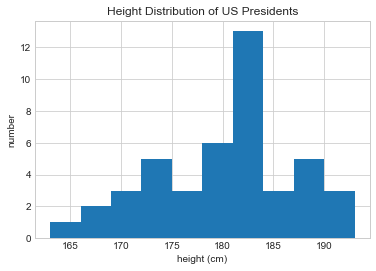

In [ ]:
plt.hist(heights)
plt.title('Height Distribution of US Presidents')
plt.xlabel('height (cm)')
plt.ylabel('number');

# Computation on Arrays: Broadcasting

We saw in [Computation on NumPy Arrays: Universal Functions](02.03-Computation-on-arrays-ufuncs.ipynb) how NumPy's universal functions can be used to *vectorize* operations and thereby remove slow Python loops.
This chapter discusses *broadcasting*: a set of rules by which NumPy lets you apply binary operations (e.g., addition, subtraction, multiplication, etc.) between arrays of different sizes and shapes.

## Introducing Broadcasting

Recall that for arrays of the same size, binary operations are performed on an element-by-element basis:

In [ ]:
import numpy as np

In [ ]:
a = np.array([0, 1, 2])
b = np.array([5, 5, 5])
a + b

array([5, 6, 7])

Broadcasting allows these types of binary operations to be performed on arrays of different sizes—for example, we can just as easily add a scalar (think of it as a zero-dimensional array) to an array:

In [ ]:
a + 5

array([5, 6, 7])

We can think of this as an operation that stretches or duplicates the value `5` into the array `[5, 5, 5]`, and adds the results.

We can similarly extend this idea to arrays of higher dimension. Observe the result when we add a one-dimensional array to a two-dimensional array:

In [ ]:
M = np.ones((3, 3))
M

array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]])

In [ ]:
M + a

array([[1., 2., 3.],
       [1., 2., 3.],
       [1., 2., 3.]])

Here the one-dimensional array `a` is stretched, or broadcasted, across the second dimension in order to match the shape of `M`.

While these examples are relatively easy to understand, more complicated cases can involve broadcasting of both arrays. Consider the following example:

In [68]:
a = np.arange(3)
b = np.arange(3)[:, np.newaxis]
c=np.arange(3)[np.newaxis,:]

print(a)
print(b)
print(c)

[0 1 2]
[[0]
 [1]
 [2]]
[[0 1 2]]


In [ ]:
a + b

array([[0, 1, 2],
       [1, 2, 3],
       [2, 3, 4]])

Just as before we stretched or broadcasted one value to match the shape of the other, here we've stretched *both* `a` and `b` to match a common shape, and the result is a two-dimensional array!
The geometry of these examples is visualized in the following figure. (Code to produce this plot can be found in the online [appendix](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/06.00-Figure-Code.ipynb#Broadcasting), and is adapted from a source published in the [astroML](http://astroml.org) documentation. Used by permission.)

![Broadcasting Visual](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/images/02.05-broadcasting.png?raw=1)

The light boxes represent the broadcasted values. This way of thinking about broadcasting may raise questions about its efficiency in terms of memory use, but worry not: NumPy broadcasting does not actually copy the broadcasted values in memory. Still, this can be a useful mental model as we think about broadcasting.

## Rules of Broadcasting

Broadcasting in NumPy follows a strict set of rules to determine the interaction between the two arrays:

- Rule 1: If the two arrays differ in their number of dimensions, the shape of the one with fewer dimensions is *padded* with ones on its leading (left) side.
- Rule 2: If the shape of the two arrays does not match in any dimension, the array with shape equal to 1 in that dimension is stretched to match the other shape.
- Rule 3: If in any dimension the sizes disagree and neither is equal to 1, an error is raised.

To make these rules clear, let's consider a few examples in detail.

### Broadcasting Example 1

Suppose we want to add a two-dimensional array to a one-dimensional array:

In [70]:
M = np.ones((2, 3))
a = np.arange(3)
M


array([[1., 1., 1.],
       [1., 1., 1.]])

Let's consider an operation on these two arrays, which have the following shapes:

- `M.shape` is `(2, 3)`
- `a.shape` is `(3,)`

We see by rule 1 that the array `a` has fewer dimensions, so we pad it on the left with ones:

- `M.shape` remains `(2, 3)`
- `a.shape` becomes `(1, 3)`

By rule 2, we now see that the first dimension disagrees, so we stretch this dimension to match:

- `M.shape` remains `(2, 3)`
- `a.shape` becomes `(2, 3)`

The shapes now match, and we see that the final shape will be `(2, 3)`:

In [ ]:
M + a

array([[1., 2., 3.],
       [1., 2., 3.]])

### Broadcasting Example 2

Now let's take a look at an example where both arrays need to be broadcast:

In [ ]:
a = np.arange(3).reshape((3, 1))
b = np.arange(3)

Again, we'll start by determining the shapes of the arrays:

- `a.shape` is `(3, 1)`
- `b.shape` is `(3,)`

Rule 1 says we must pad the shape of `b` with ones:

- `a.shape` remains `(3, 1)`
- `b.shape` becomes `(1, 3)`

And rule 2 tells us that we must upgrade each of these ``1``s to match the corresponding size of the other array:

- `a.shape` becomes `(3, 3)`
- `b.shape` becomes `(3, 3)`

Because the results match, these shapes are compatible. We can see this here:

In [ ]:
a + b

array([[0, 1, 2],
       [1, 2, 3],
       [2, 3, 4]])

### Broadcasting Example 3

Next, let's take a look at an example in which the two arrays are not compatible:

In [ ]:
M = np.ones((3, 2))
a = np.arange(3)

This is just a slightly different situation than in the first example: the matrix `M` is transposed.
How does this affect the calculation? The shapes of the arrays are as follows:

- `M.shape` is `(3, 2)`
- `a.shape` is `(3,)`

Again, rule 1 tells us that we must pad the shape of `a` with ones:

- `M.shape` remains `(3, 2)`
- `a.shape` becomes `(1, 3)`

By rule 2, the first dimension of `a` is then stretched to match that of `M`:

- `M.shape` remains `(3, 2)`
- `a.shape` becomes `(3, 3)`

Now we hit rule 3—the final shapes do not match, so these two arrays are incompatible, as we can observe by attempting this operation:

In [ ]:
M + a

ValueError: operands could not be broadcast together with shapes (3,2) (3,) 

Note the potential confusion here: you could imagine making `a` and `M` compatible by, say, padding `a`'s shape with ones on the right rather than the left.
But this is not how the broadcasting rules work!
That sort of flexibility might be useful in some cases, but it would lead to potential areas of ambiguity.
If right-side padding is what you'd like, you can do this explicitly by reshaping the array (we'll use the `np.newaxis` keyword introduced in [The Basics of NumPy Arrays](02.02-The-Basics-Of-NumPy-Arrays.ipynb) for this):

In [ ]:
a[:, np.newaxis].shape

(3, 1)

In [ ]:
M + a[:, np.newaxis]

array([[1., 1.],
       [2., 2.],
       [3., 3.]])

Also notice that while we've been focusing on the `+` operator here, these broadcasting rules apply to *any* binary ufunc.
For example, here is the `logaddexp(a, b)` function, which computes `log(exp(a) + exp(b))` with more precision than the naive approach:

In [ ]:
np.logaddexp(M, a[:, np.newaxis])

array([[1.31326169, 1.31326169],
       [1.69314718, 1.69314718],
       [2.31326169, 2.31326169]])

For more information on the many available universal functions, refer to [Computation on NumPy Arrays: Universal Functions](02.03-Computation-on-arrays-ufuncs.ipynb).

## Broadcasting in Practice

Broadcasting operations form the core of many examples you'll see throughout this book.
We'll now take a look at some instances of where they can be useful.

### Centering an Array

In [Computation on NumPy Arrays: Universal Functions](02.03-Computation-on-arrays-ufuncs.ipynb), we saw that ufuncs allow a NumPy user to remove the need to explicitly write slow Python loops. Broadcasting extends this ability.
One commonly seen example in data science is subtracting the row-wise mean from an array of data.
Imagine we have an array of 10 observations, each of which consists of 3 values.
Using the standard convention (see [Data Representation in Scikit-Learn](05.02-Introducing-Scikit-Learn.ipynb#Data-Representation-in-Scikit-Learn)), we'll store this in a $10 \times 3$ array:

In [72]:
rng = np.random.default_rng(seed=1701)
X = rng.random((10, 3))

We can compute the mean of each column using the `mean` aggregate across the first dimension:

In [77]:
Xmean = X.mean(axis=0) #or just X.mean(0) is also fine,  the arguement is axis by default
Xmean

array([0.38503638, 0.36991443, 0.63896043])

And now we can center the `X` array by subtracting the mean (this is a broadcasting operation):

In [ ]:
X_centered = X - Xmean  #X is 10x3   while Xmean is 1x3 , so it automaticaly scales to 10x3 and then operation is performed

To double-check that we've done this correctly, we can check that the centered array has a mean near zero:

In [ ]:
X_centered.mean(0)

array([ 4.99600361e-17, -4.44089210e-17,  0.00000000e+00])

To within machine precision, the mean is now zero.

### Plotting a Two-Dimensional Function

One place that broadcasting often comes in handy is in displaying images based on two-dimensional functions.
If we want to define a function $z = f(x, y)$, broadcasting can be used to compute the function across the grid:

In [78]:
# x and y have 50 steps from 0 to 5
x = np.linspace(0, 5, 50)
print(x)
y = np.linspace(0, 5, 50)[:, np.newaxis]

z = np.sin(x) ** 10 + np.cos(10 + y * x) * np.cos(x)

[0.         0.10204082 0.20408163 0.30612245 0.40816327 0.51020408
 0.6122449  0.71428571 0.81632653 0.91836735 1.02040816 1.12244898
 1.2244898  1.32653061 1.42857143 1.53061224 1.63265306 1.73469388
 1.83673469 1.93877551 2.04081633 2.14285714 2.24489796 2.34693878
 2.44897959 2.55102041 2.65306122 2.75510204 2.85714286 2.95918367
 3.06122449 3.16326531 3.26530612 3.36734694 3.46938776 3.57142857
 3.67346939 3.7755102  3.87755102 3.97959184 4.08163265 4.18367347
 4.28571429 4.3877551  4.48979592 4.59183673 4.69387755 4.79591837
 4.89795918 5.        ]


We'll use Matplotlib to plot this two-dimensional array, shown in the following figure (these tools will be discussed in full in [Density and Contour Plots](04.04-Density-and-Contour-Plots.ipynb)):

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

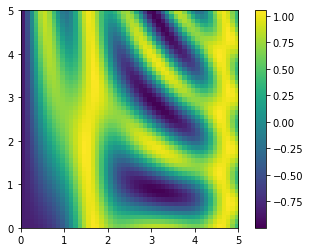

In [ ]:
plt.imshow(z, origin='lower', extent=[0, 5, 0, 5])
plt.colorbar();

The result is a compelling visualization of the two-dimensional function.